# FDA AEMS Exploratory Data Analysis Pipeline (Polars Parquet Optimized)
This notebook is specifically designed for high-performance EDA on large FAERS/AEMS Parquet files using **Polars' Lazy API**.

### Why `scan_parquet`?
- **Memory Safety**: It won't crash if the file is larger than your RAM.
- **Lazy Execution**: Polars builds a plan and only executes it when you call `.collect()`.
- **Predicate Pushdown**: If you filter or select specific columns, Polars only reads those parts of the Parquet file.

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Scan Parquet File
Using `scan_parquet` creates a `LazyFrame`. Update the file path below to point to your dataset.

In [2]:
# Update this path to your parquet file
FILE_PATH = 'FAERS_final.parquet'

# Create a LazyFrame
lf = pl.scan_parquet(FILE_PATH)

print("LazyFrame initialized. No data loaded into memory yet.")
# To see a sample without loading everything, use .head().collect()
lf.head().collect()

LazyFrame initialized. No data loaded into memory yet.


primaryid,caseid,role_cod,rx_name,dose_amt,dose_unit,dose_form,sex,sex_bin,age_years,wt_kg,outcome_death,outcome_life_threatening,outcome_hospitalisation,outcome_disability,outcome_congenital_anomaly,outcome_intervention_required,outcome_other_serious,reactions
i64,i64,str,str,str,str,str,str,i8,f64,f64,bool,bool,bool,bool,bool,bool,bool,list[str]
239373571,23937357,"""PS""","""TERBINAFINE""","""250""","""MG""",null,"""M""",0,50.0,null,true,false,false,false,false,false,true,"[""Condition aggravated"", ""Drug ineffective for unapproved indication""]"
239373571,23937357,"""SS""","""AMPHOTERICIN B""",null,null,null,"""M""",0,50.0,null,true,false,false,false,false,false,true,"[""Condition aggravated"", ""Drug ineffective for unapproved indication""]"
239373571,23937357,"""SS""","""VORICONAZOLE""",null,null,null,"""M""",0,50.0,null,true,false,false,false,false,false,true,"[""Condition aggravated"", ""Drug ineffective for unapproved indication""]"
194512131,19451213,"""PS""","""ONGENTYS""","""50""","""MG""","""CAPSULE""",null,null,null,null,null,null,null,null,null,null,null,"[""Somnolence""]"
194512131,19451213,"""C""","""LOSARTAN POTASSIUM""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,"[""Somnolence""]"


## 2. Optimized Preprocessing Pipeline
We define all transformations in the LazyFrame before triggering the computation.

In [3]:
# Identify outcome columns
# In a LazyFrame, we can use pl.selectors if using latest polars, 
# but standard column names work best for cross-version compatibility.
outcome_cols = [
    'outcome_death', 'outcome_life_threatening', 'outcome_hospitalisation',
    'outcome_disability', 'outcome_congenital_anomaly', 
    'outcome_intervention_required', 'outcome_other_serious'
]

processed_lf = lf.with_columns([
    # Convert outcome flags to booleans (handling string or int types)
    pl.col(outcome_cols).cast(pl.Boolean).fill_null(False),
    
    # Clean and split the reactions string column into a list
    pl.col("reactions").str.strip_chars("[]").str.replace_all('"', '').str.split(", ").alias("reactions_list")
])

print("Preprocessing pipeline defined.")

Preprocessing pipeline defined.


## 3. EDA - Computation and Viz
To visualize, we aggregate the data inside the LazyFrame first to reduce the size, then `.collect()` the result for plotting.

C:\Users\Cole\AppData\Local\Temp\ipykernel_6968\1193300778.py:4: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  schema = lf.schema
C:\Users\Cole\AppData\Local\Temp\ipykernel_6968\1193300778.py:22: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  outcome_cols = [c for c in lf.columns if c.startswith('outcome_')]


Detected 'reactions' column type: List(String)


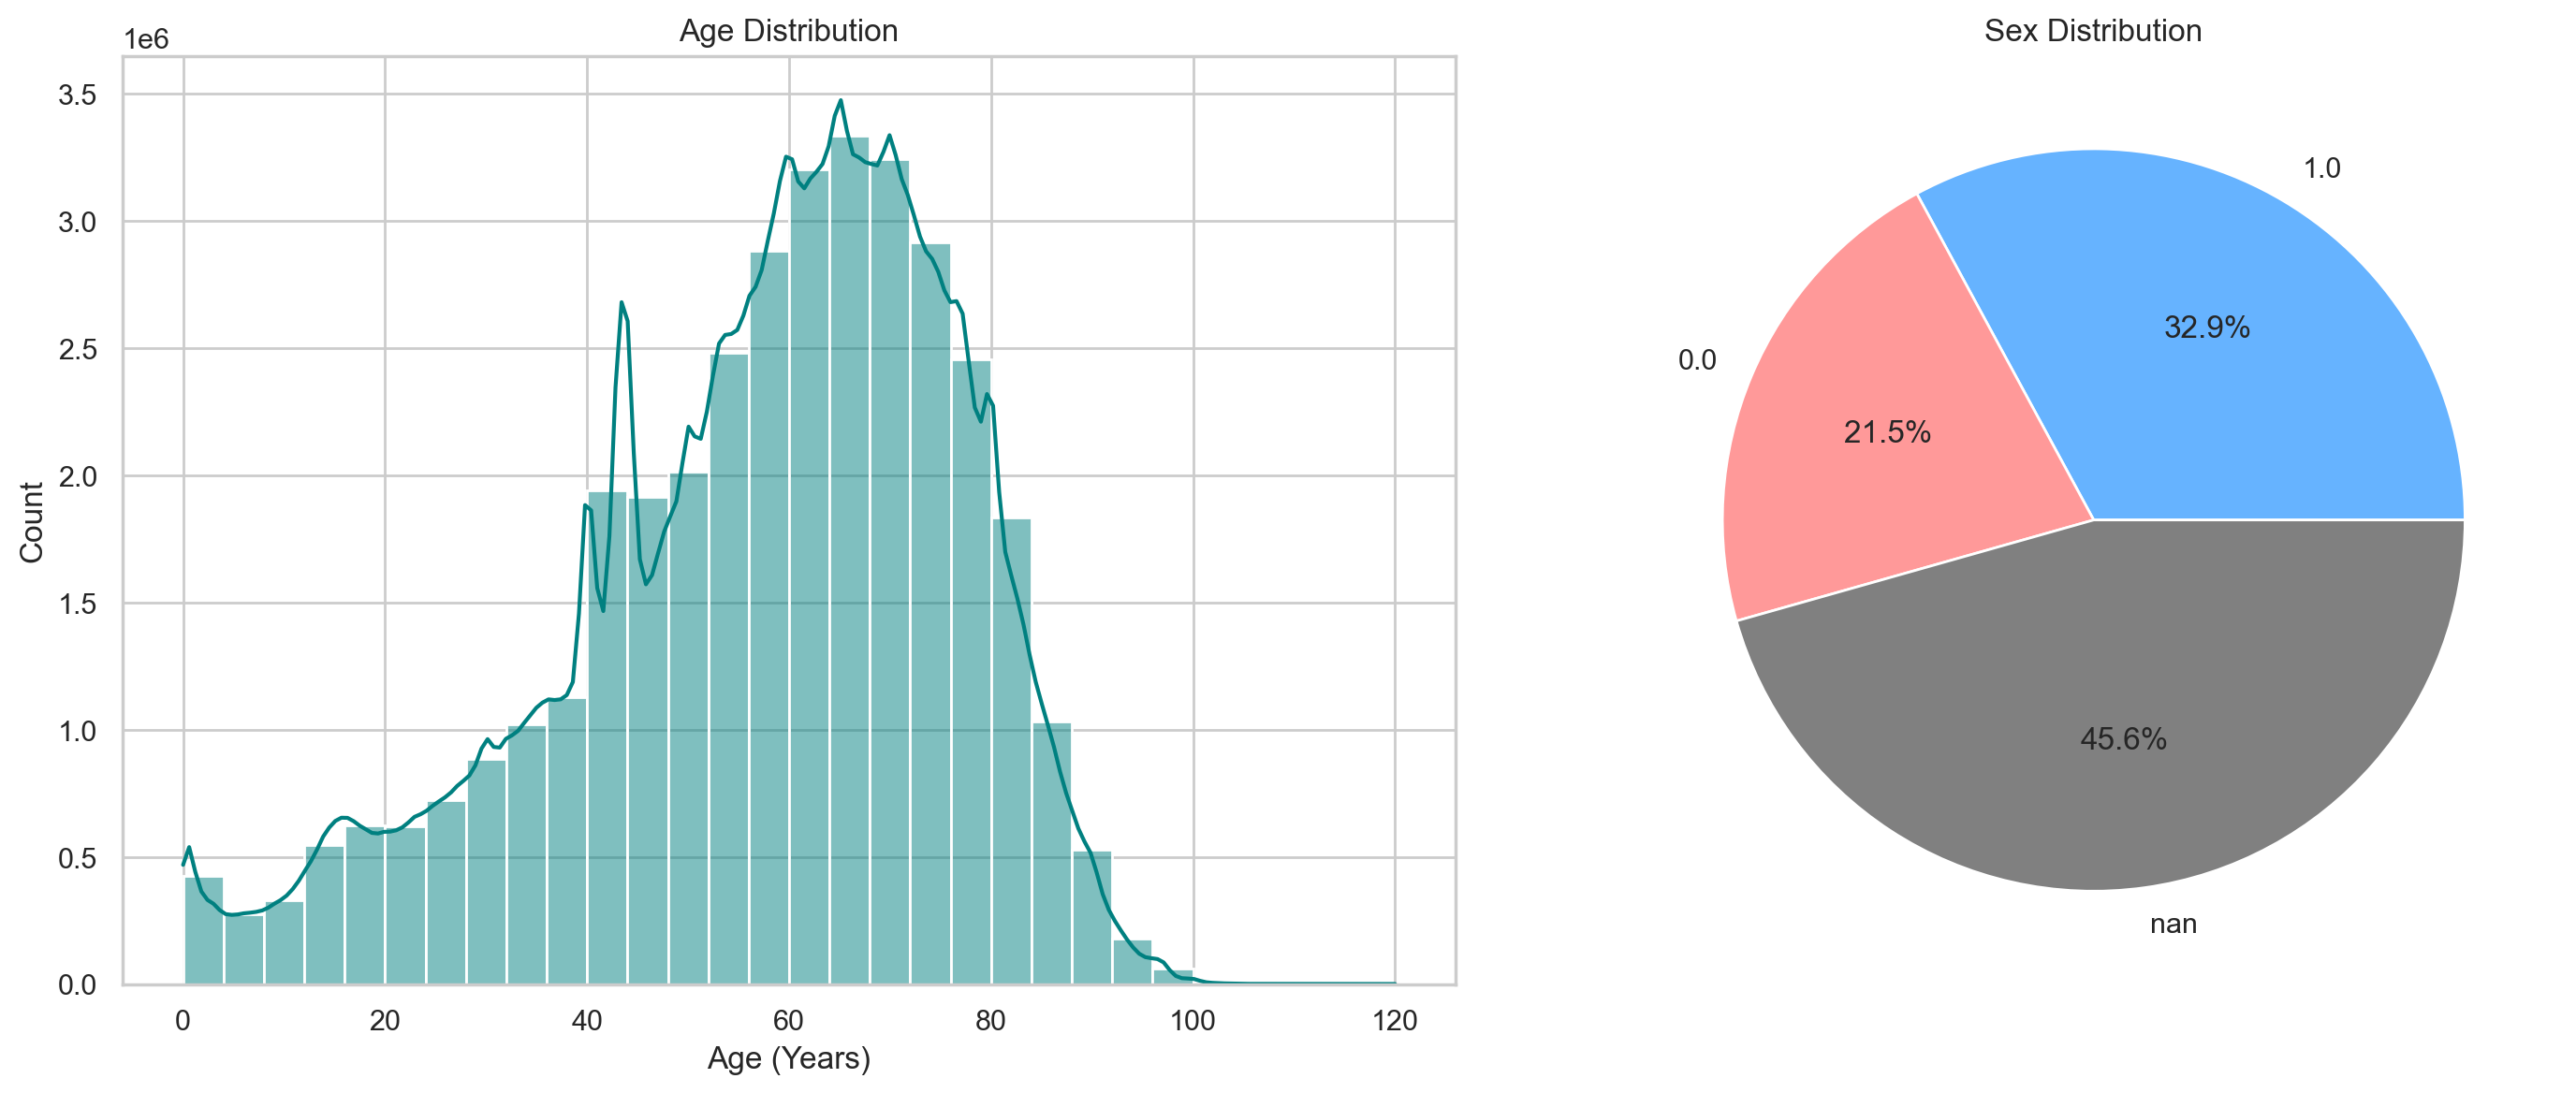

In [15]:
### A. Demographic Summary

# 1. Inspect the schema of the LazyFrame to see what 'reactions' actually is
schema = lf.schema
reactions_dtype = schema.get("reactions")
print(f"Detected 'reactions' column type: {reactions_dtype}")

# 2. Define the reaction parsing logic based on the detected type
if reactions_dtype == pl.String:
    # If it's a string like '["Nausea"]', we parse it
    reactions_expr = (
        pl.col("reactions")
        .str.strip_chars("[]")
        .str.replace_all('"', '')
        .str.split(", ")
    )
else:
    # If it's already a list (list[str]), we just use it as is
    reactions_expr = pl.col("reactions")

# 3. Re-define the processing pipeline
outcome_cols = [c for c in lf.columns if c.startswith('outcome_')]

processed_lf = lf.with_columns([
    # Clean boolean outcomes
    pl.col(outcome_cols).cast(pl.Boolean).fill_null(False),
    
    # Apply the logic determined above
    reactions_expr.alias("reactions_list")
])

# 4. Execute the Demographic Viz
try:
    # We only collect the columns we need for this plot to save memory
    age_sex_data = processed_lf.select(["age_years", "sex_bin"]).collect()

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Age Distribution
    sns.histplot(age_sex_data['age_years'].to_pandas().dropna(), bins=30, kde=True, ax=axes[0], color='teal')
    axes[0].set_title('Age Distribution')
    axes[0].set_xlabel('Age (Years)')

    # Sex Distribution
    sex_counts = age_sex_data['sex_bin'].value_counts().to_pandas()
    axes[1].pie(sex_counts['count'], labels=sex_counts['sex_bin'], autopct='%1.1f%%', colors=['#66b3ff', '#ff9999', '#808080'])
    axes[1].set_title('Sex Distribution')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error during collection: {e}")

C:\Users\Cole\AppData\Local\Temp\ipykernel_6968\3973681079.py:4: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  outcome_cols = [c for c in lf.columns if c.startswith('outcome_')]


Computing outcome prevalence...


C:\Users\Cole\AppData\Local\Temp\ipykernel_6968\3973681079.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


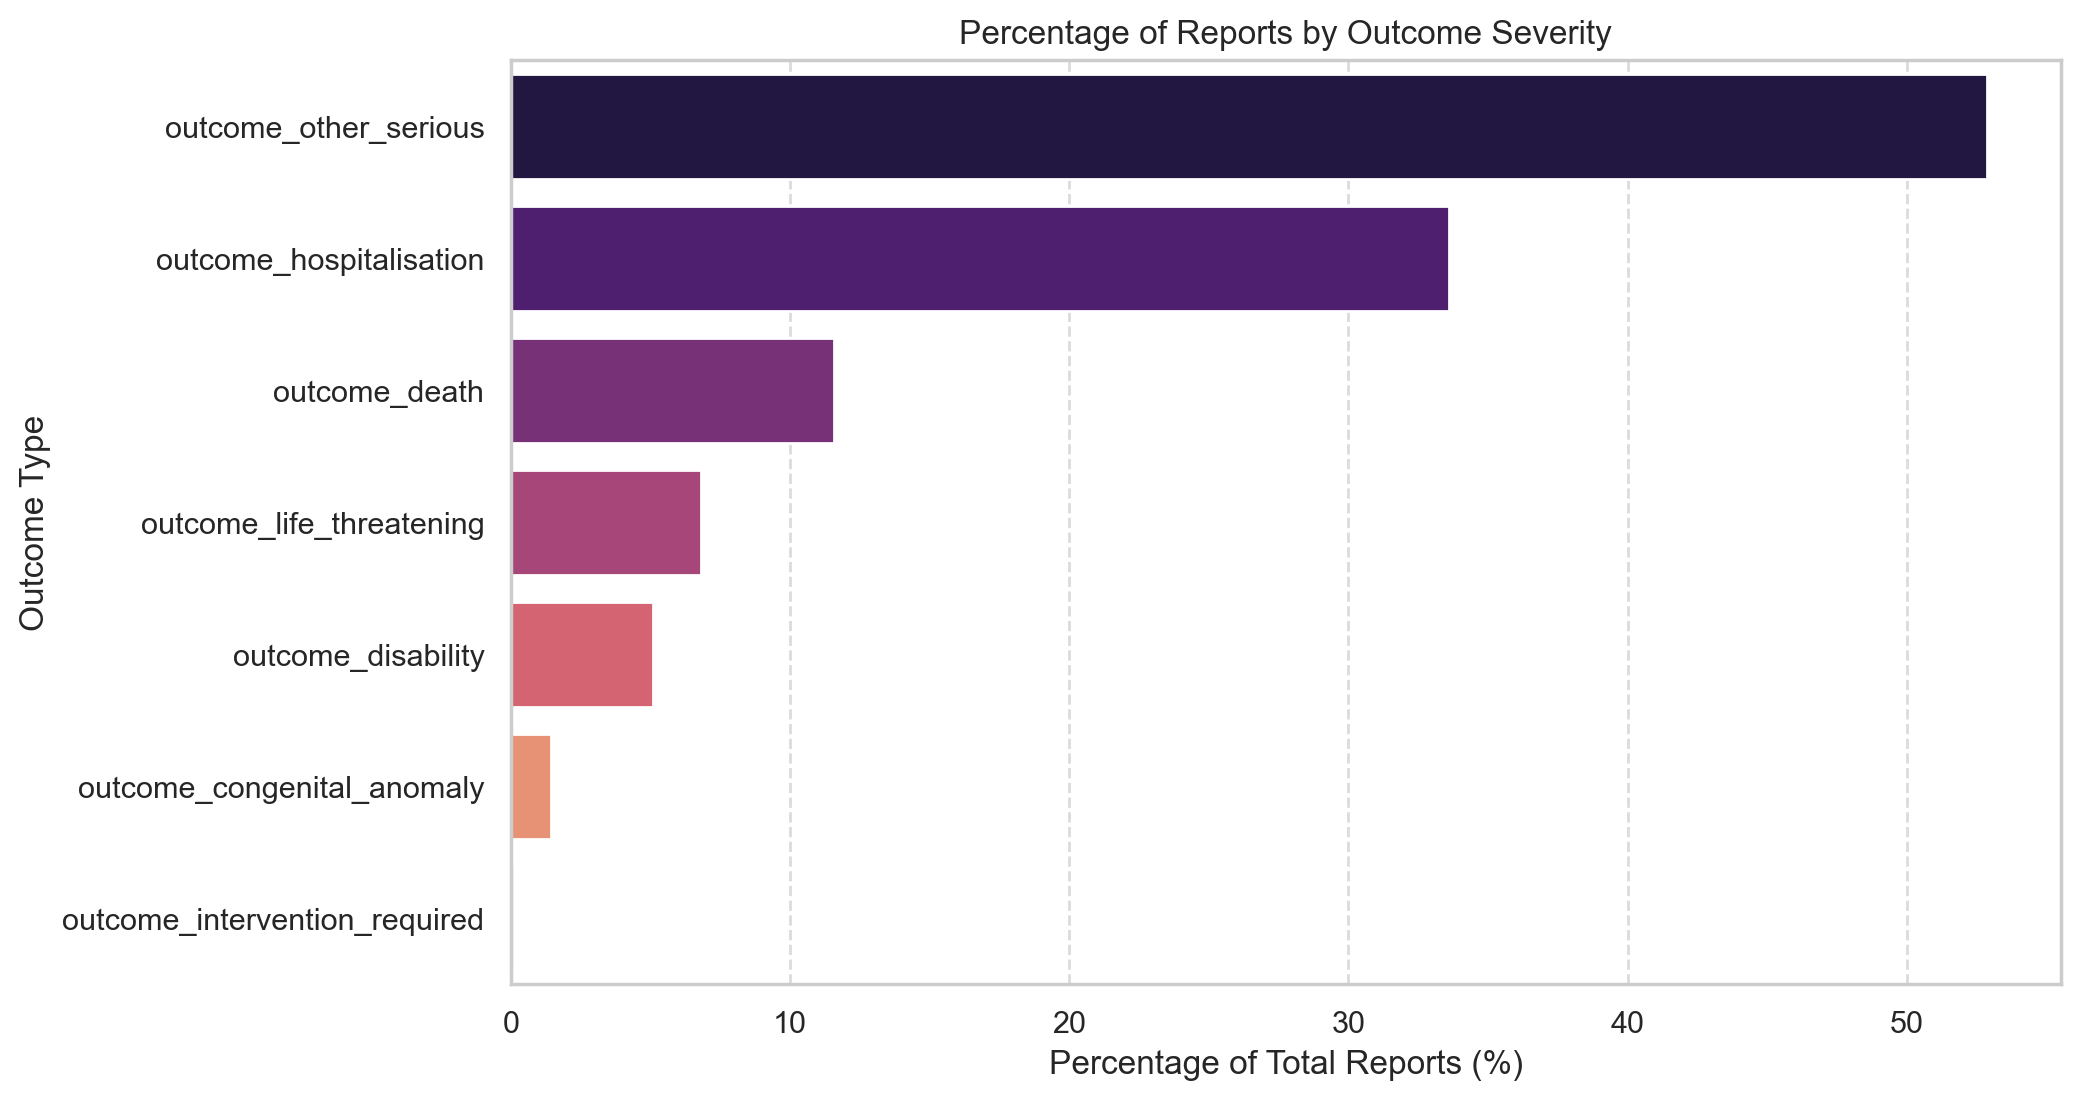

In [5]:
### B. Severity Prevalence

# 1. Ensure outcome_cols are identified from the schema
outcome_cols = [c for c in lf.columns if c.startswith('outcome_')]

# 2. Compute the mean of the boolean flags (Prevalence)
# We use the processed_lf defined in Section A which already has the fixes
try:
    print("Computing outcome prevalence...")
    severity_stats = (
        processed_lf.select(pl.col(outcome_cols).mean() * 100)
        .collect()
        .to_pandas()
        .transpose()
    )
    
    severity_stats.columns = ['Percentage (%)']
    severity_stats = severity_stats.sort_values('Percentage (%)', ascending=False)

    # 3. Plotting
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=severity_stats['Percentage (%)'], 
        y=severity_stats.index, 
        palette='magma'
    )
    plt.title('Percentage of Reports by Outcome Severity')
    plt.xlabel('Percentage of Total Reports (%)')
    plt.ylabel('Outcome Type')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

except Exception as e:
    print(f"Error computing severity prevalence: {e}")

Calculating Top 10 lists using Streaming Engine...


C:\Users\Cole\AppData\Local\Temp\ipykernel_6968\2145030173.py:31: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  top_drugs = top_drugs_lf.collect(streaming=True)
C:\Users\Cole\AppData\Local\Temp\ipykernel_6968\2145030173.py:32: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  top_reactions = top_reactions_lf.collect(streaming=True)
C:\Users\Cole\AppData\Local\Temp\ipykernel_6968\2145030173.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_drugs.to_pandas(), x="len", y="rx_name", palette="Blues_r", ax=axes[0])
C:\Users\Cole\AppData\Local\Temp\ipykernel_6968\2145030173.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False`

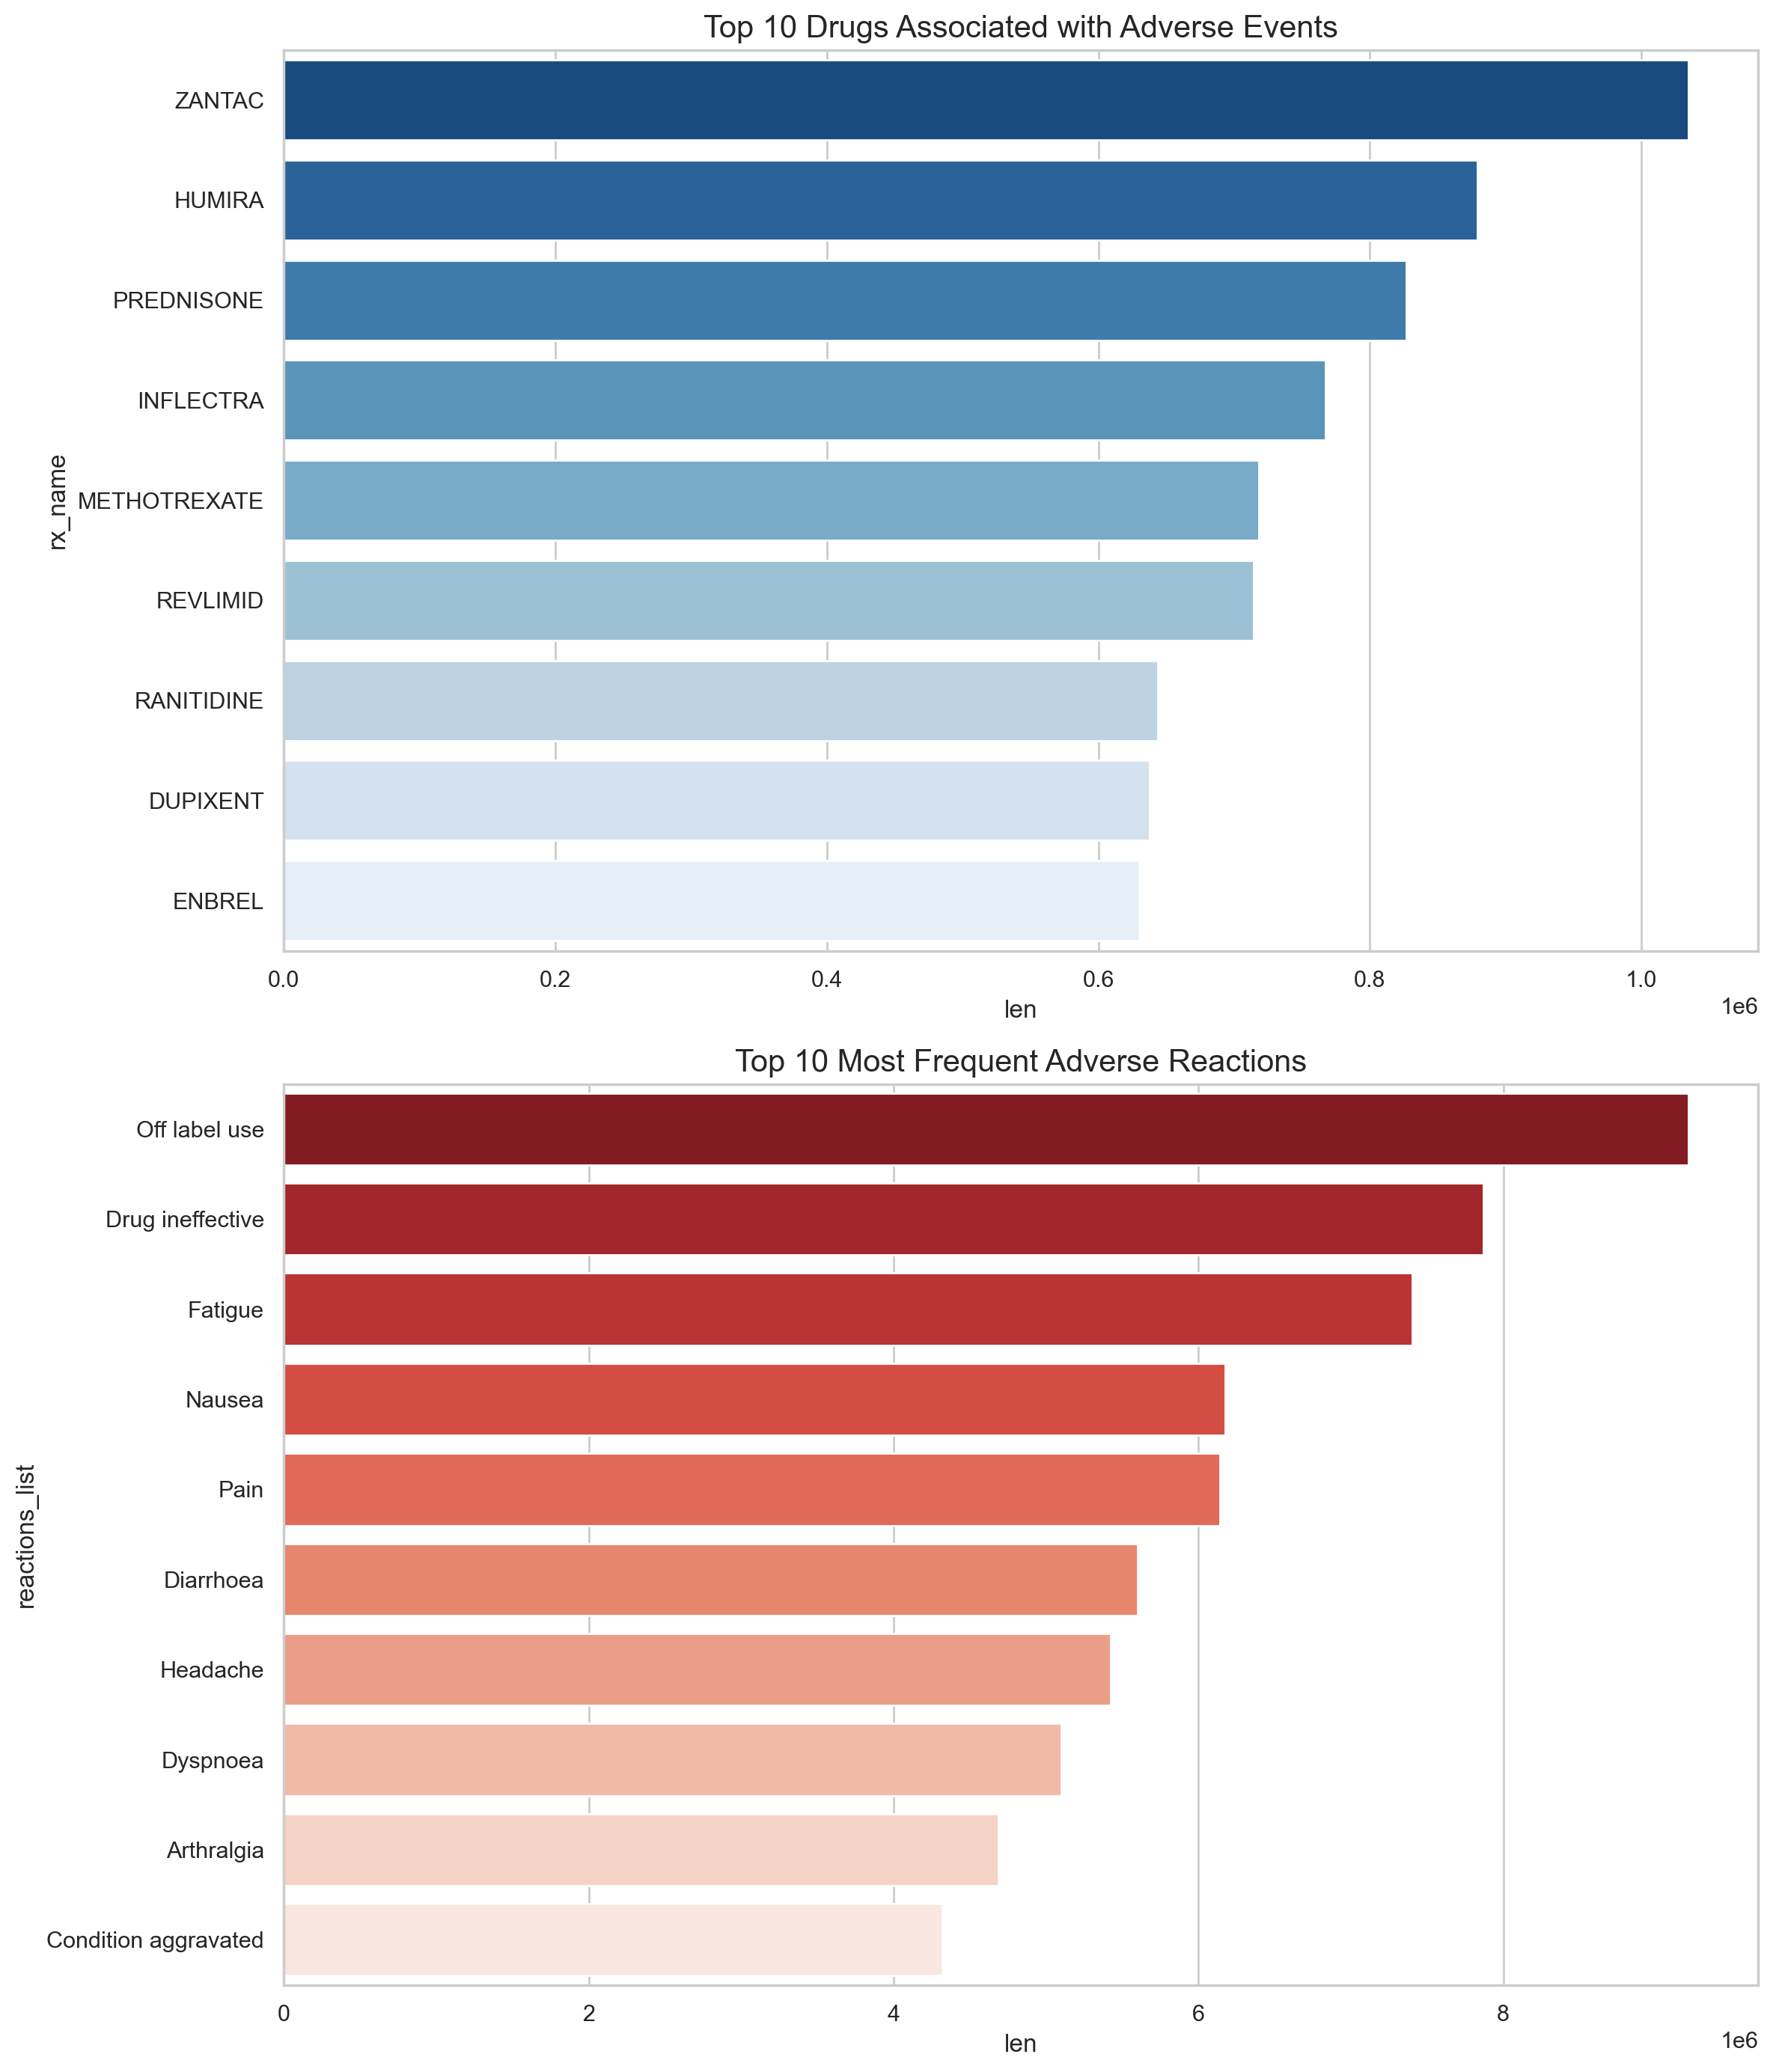

In [6]:
### C. Top 10 Drugs and Reactions (Optimized)

# 1. Process Top Drugs 
# Use .len() instead of .count() for a slight speed boost in newer Polars
top_drugs_lf = (
    processed_lf
    .group_by("rx_name")
    .len() 
    .sort("len", descending=True)
    .head(10)
)

# 2. Process Top Reactions (THE OPTIMIZED PART)
top_reactions_lf = (
    processed_lf
    .select("reactions_list")
    # Drop nulls/empty lists BEFORE exploding to save memory
    .drop_nulls() 
    .explode("reactions_list")
    .filter(pl.col("reactions_list") != "")
    .group_by("reactions_list")
    .len()
    .sort("len", descending=True)
    .head(10)
)

# 3. Trigger computation (Streaming mode is key for 81M rows!)
print("Calculating Top 10 lists using Streaming Engine...")

# We use streaming=True to handle the 400M+ exploded rows without crashing RAM
top_drugs = top_drugs_lf.collect(streaming=True)
top_reactions = top_reactions_lf.collect(streaming=True)

# 4. Plotting (Updating column names to 'len' from 'count')
fig, axes = plt.subplots(2, 1, figsize=(12, 14))

# Drug Chart
sns.barplot(data=top_drugs.to_pandas(), x="len", y="rx_name", palette="Blues_r", ax=axes[0])
axes[0].set_title("Top 10 Drugs Associated with Adverse Events", fontsize=15)

# Reaction Chart
sns.barplot(data=top_reactions.to_pandas(), x="len", y="reactions_list", palette="Reds_r", ax=axes[1])
axes[1].set_title("Top 10 Most Frequent Adverse Reactions", fontsize=15)

plt.tight_layout()
plt.show()

C:\Users\Cole\AppData\Local\Temp\ipykernel_6968\481050331.py:4: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  outcome_cols = [c for c in lf.columns if c.startswith('outcome_')]


Calculating correlation matrix for 81M rows...


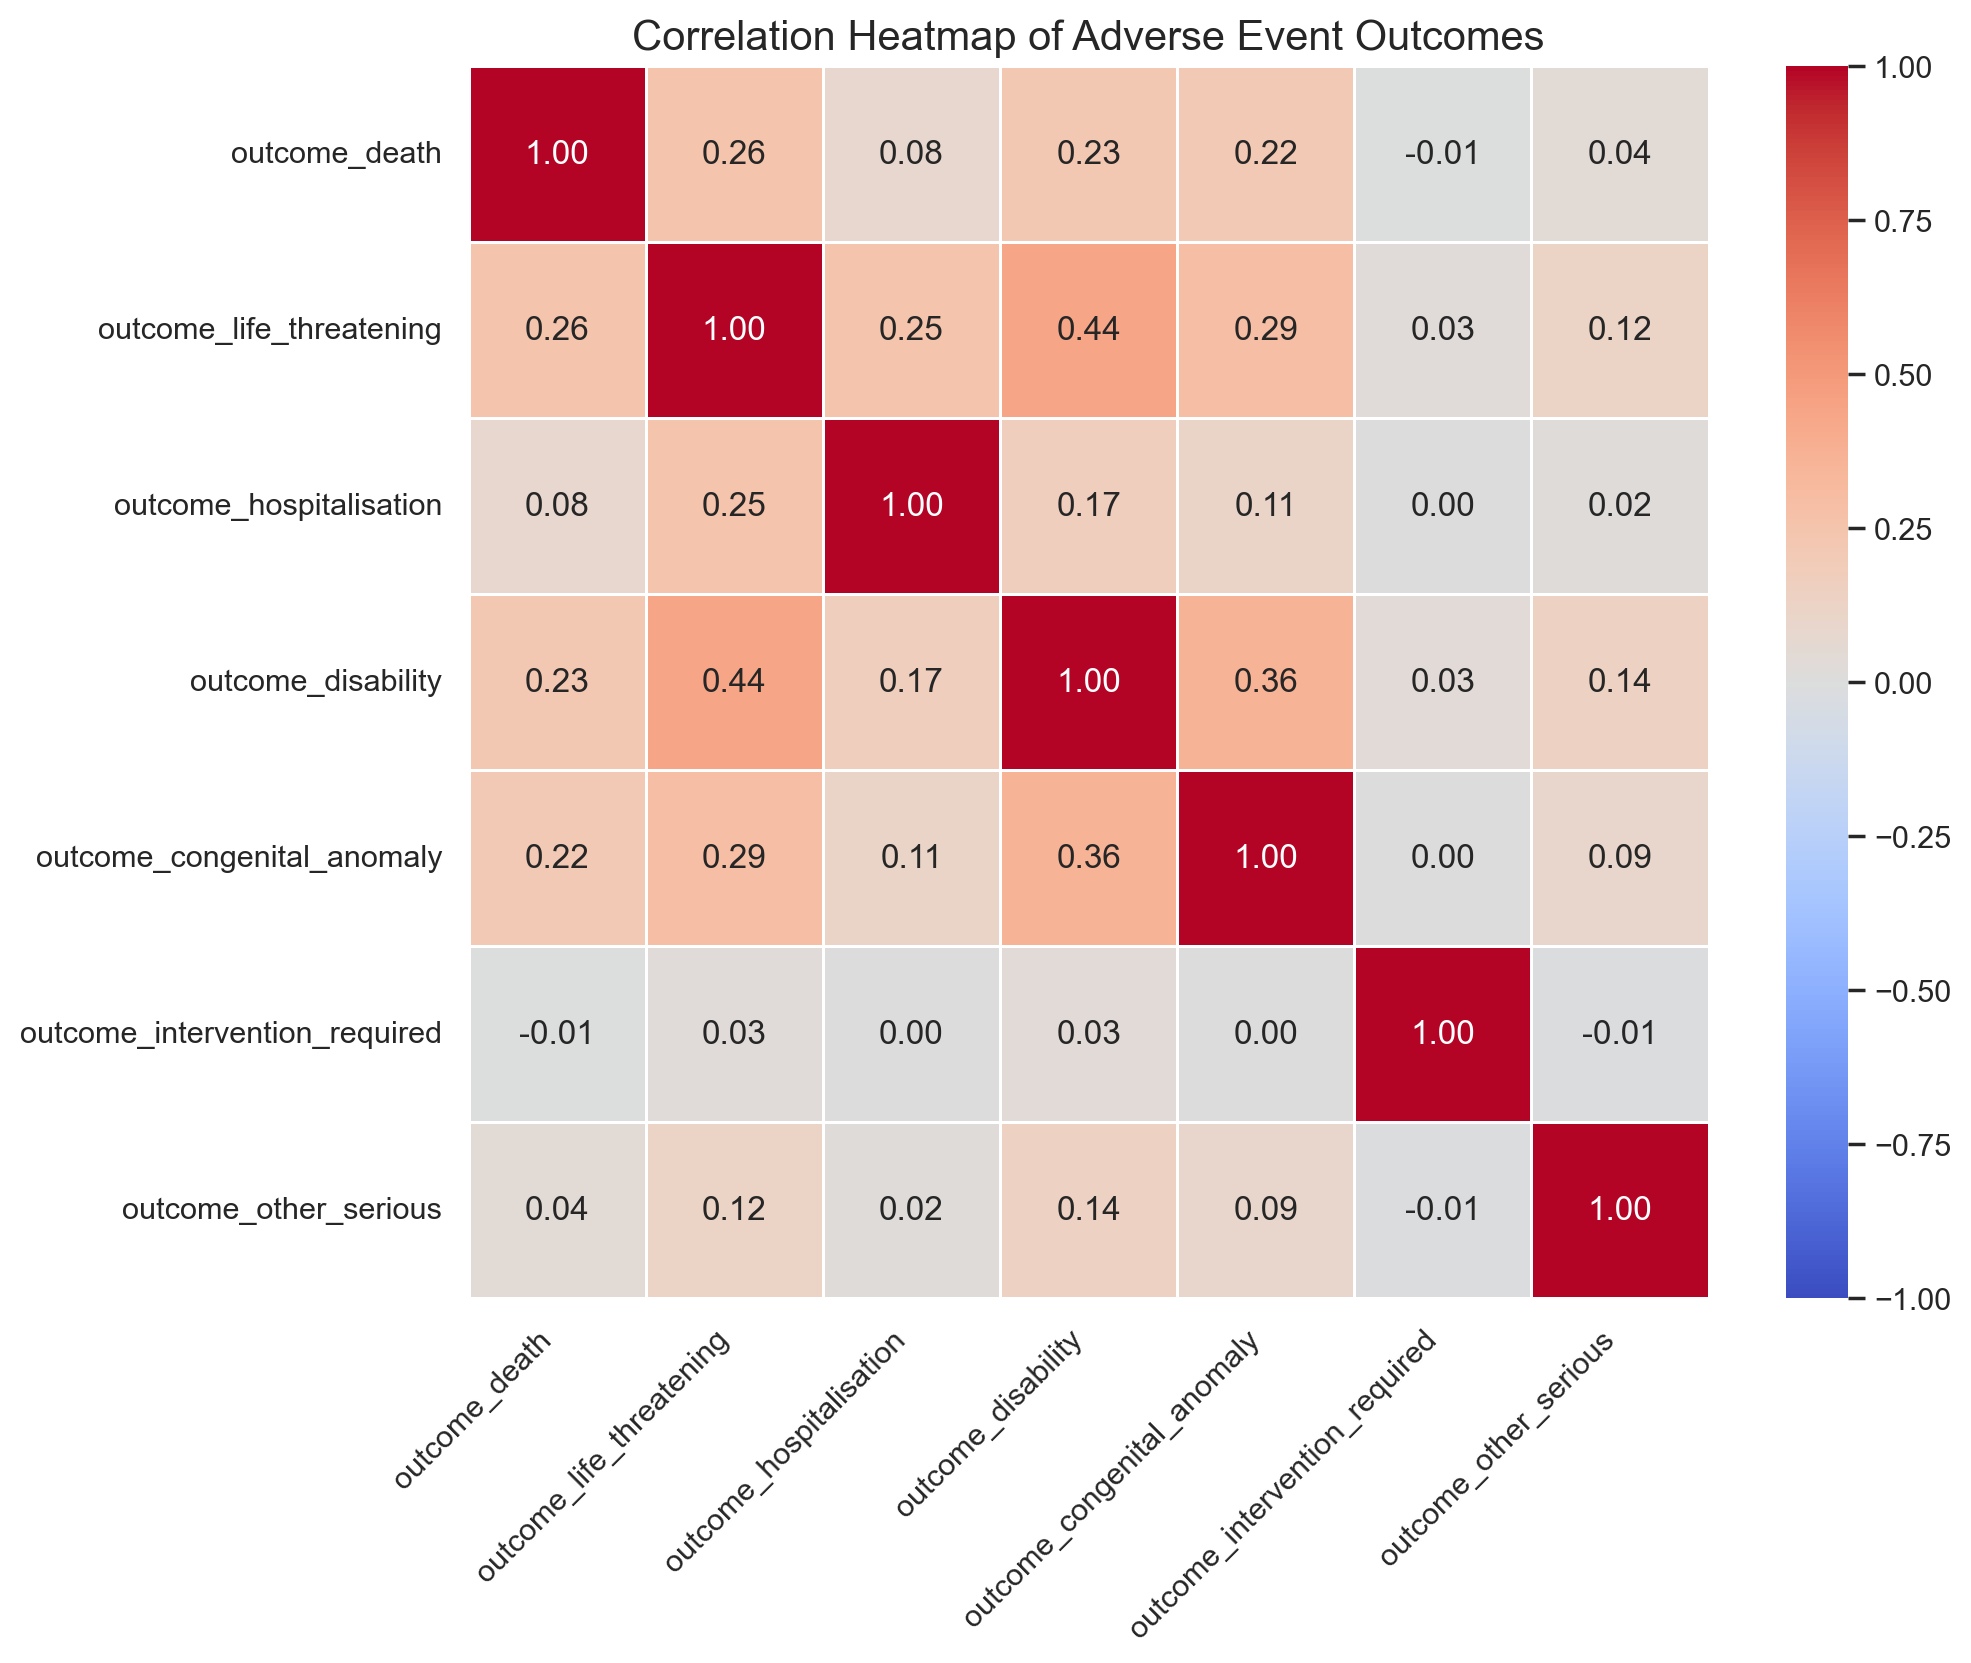

In [7]:
### D. Correlation Analysis of Outcomes

# 1. Select only outcome columns and cast to integers for correlation math
outcome_cols = [c for c in lf.columns if c.startswith('outcome_')]

print("Calculating correlation matrix for 81M rows...")

# We collect only these 7 columns. 
# 81M rows of integers for 7 columns is ~600MB, which fits in memory easily.
correlation_data = (
    processed_lf
    .select(pl.col(outcome_cols).cast(pl.Int8))
    .collect()
    .to_pandas()
)

# 2. Compute the Pearson correlation matrix
corr_matrix = correlation_data.corr()

# 3. Plotting the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5,
    vmin=-1, vmax=1
)

plt.title('Correlation Heatmap of Adverse Event Outcomes', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.show()

Calculating missing value percentages using Streaming Engine...


C:\Users\Cole\AppData\Local\Temp\ipykernel_6968\2845245067.py:10: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True) # CRITICAL: Processes data in batches


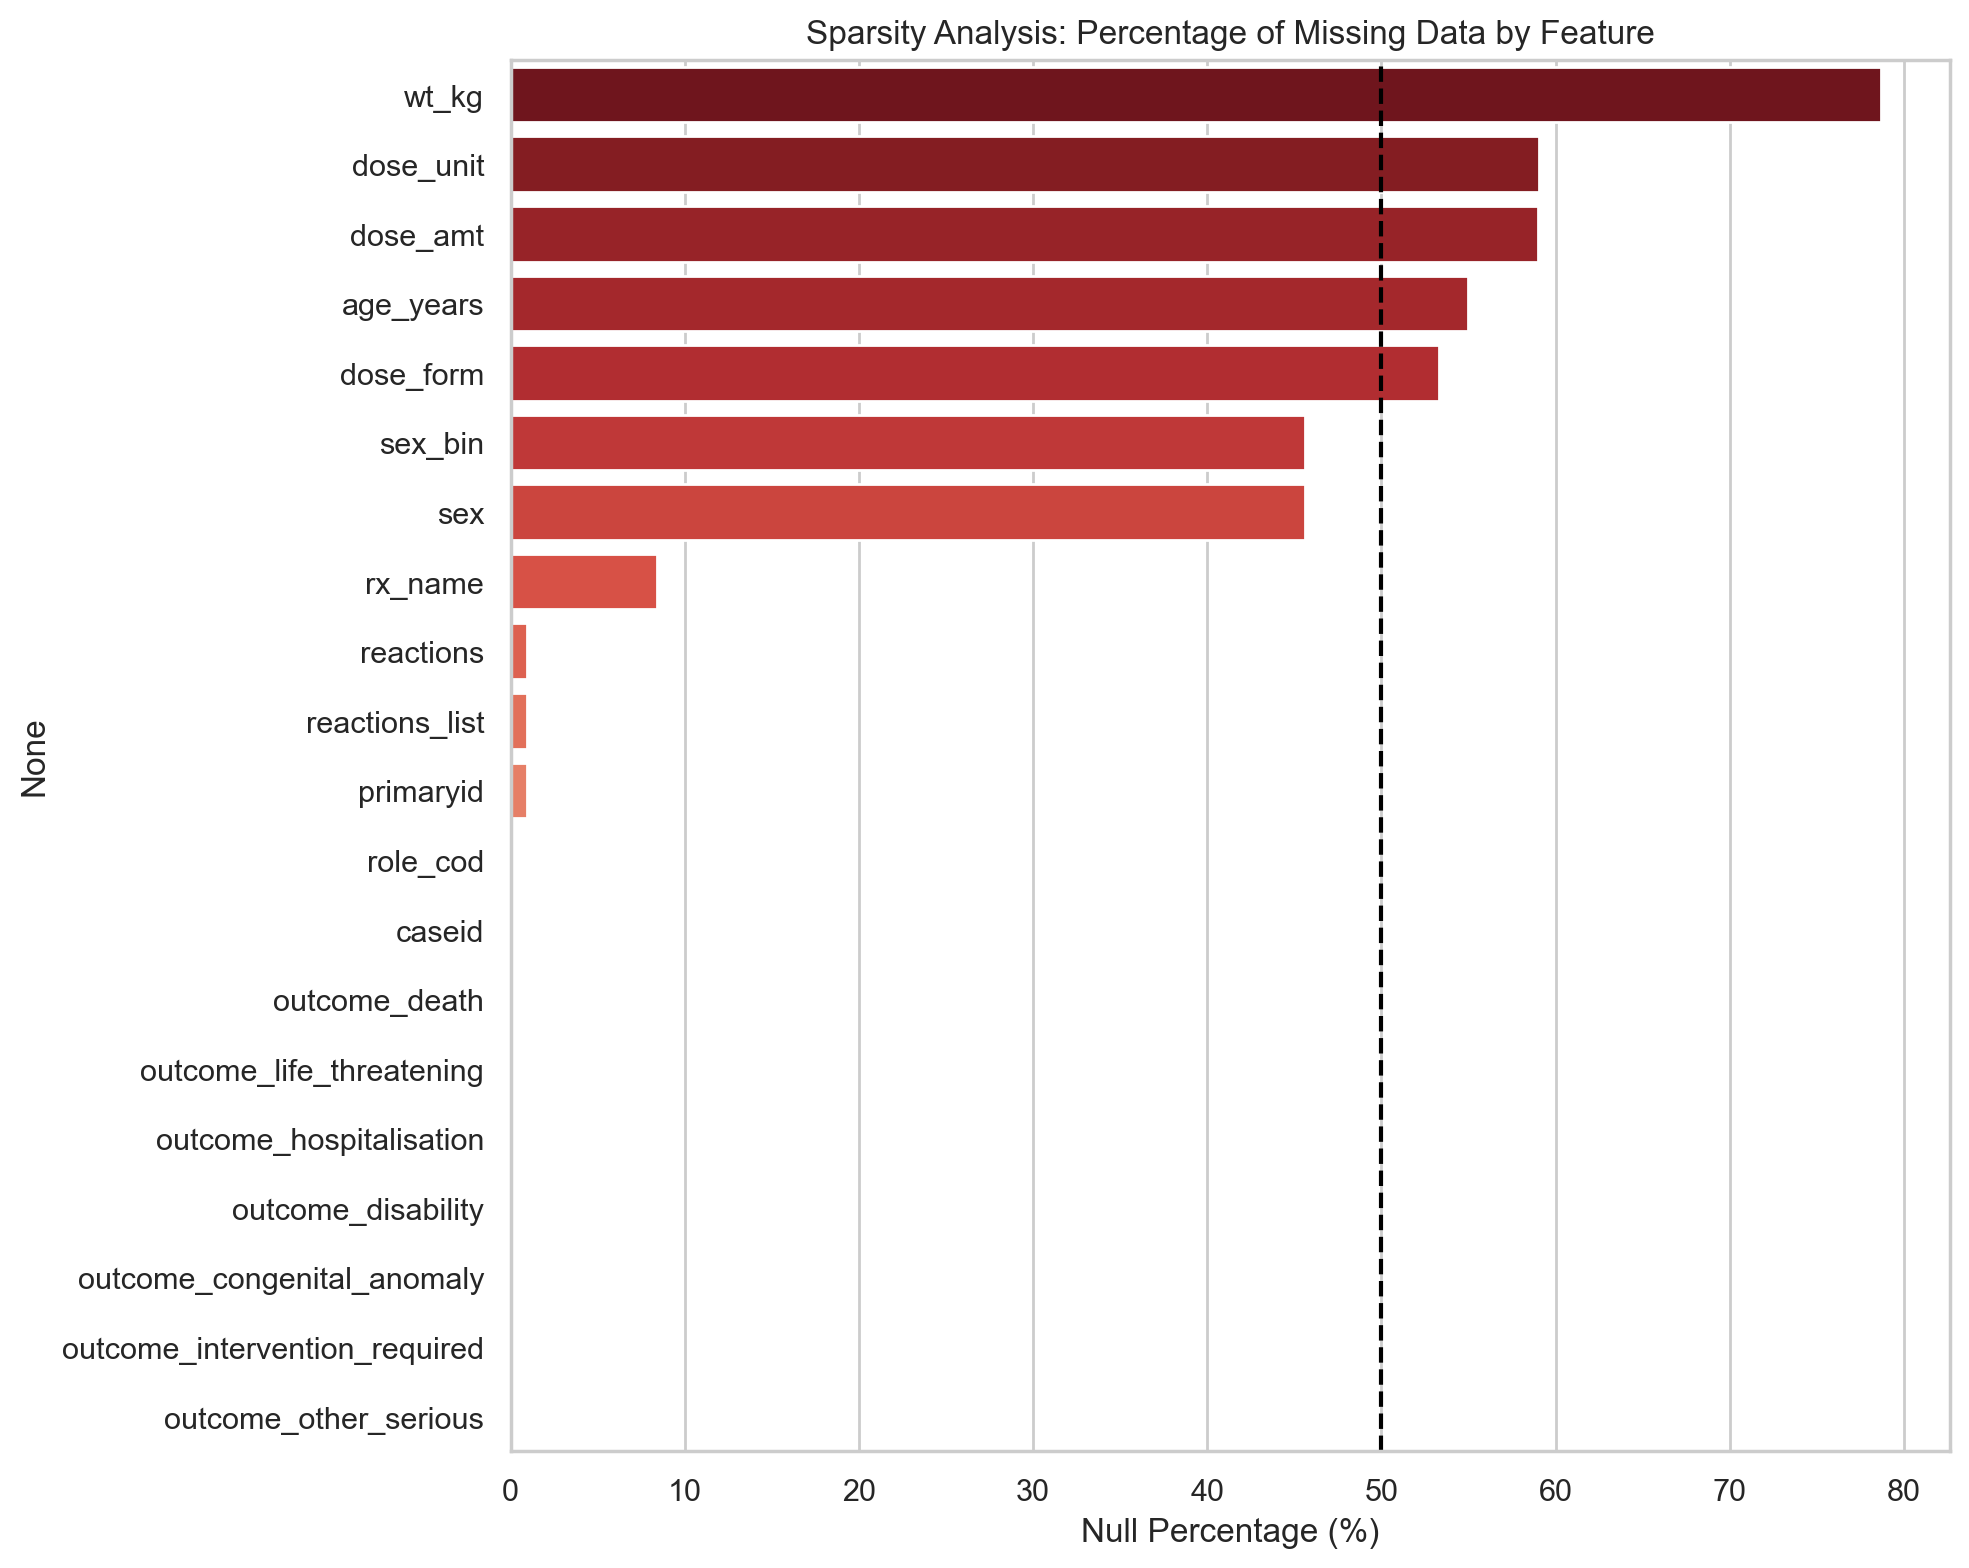

In [8]:
### E. Sparsity Analysis (High Performance)
print("Calculating missing value percentages using Streaming Engine...")

# Calculate null counts for all columns using the streaming engine
# This avoids loading the full 81M rows into memory
null_analysis_df = (
    processed_lf.select([
        (pl.all().null_count() / pl.len() * 100)
    ])
    .collect(streaming=True) # CRITICAL: Processes data in batches
    .to_pandas()
    .transpose()
)

# Rename and Sort
null_analysis_df.columns = ['Null Percentage (%)']
null_analysis_df = null_analysis_df.sort_values('Null Percentage (%)', ascending=False)

# Visualization
plt.figure(figsize=(10, 8))
sns.barplot(
    x=null_analysis_df['Null Percentage (%)'], 
    y=null_analysis_df.index, 
    hue=null_analysis_df.index,
    palette='Reds_r',
    legend=False
)

plt.title('Sparsity Analysis: Percentage of Missing Data by Feature')
plt.axvline(50, color='black', linestyle='--')
plt.tight_layout()
plt.show()

C:\Users\Cole\AppData\Local\Temp\ipykernel_6968\2506742800.py:6: DeprecationWarning: `count` was renamed; use `len` instead
  .count()


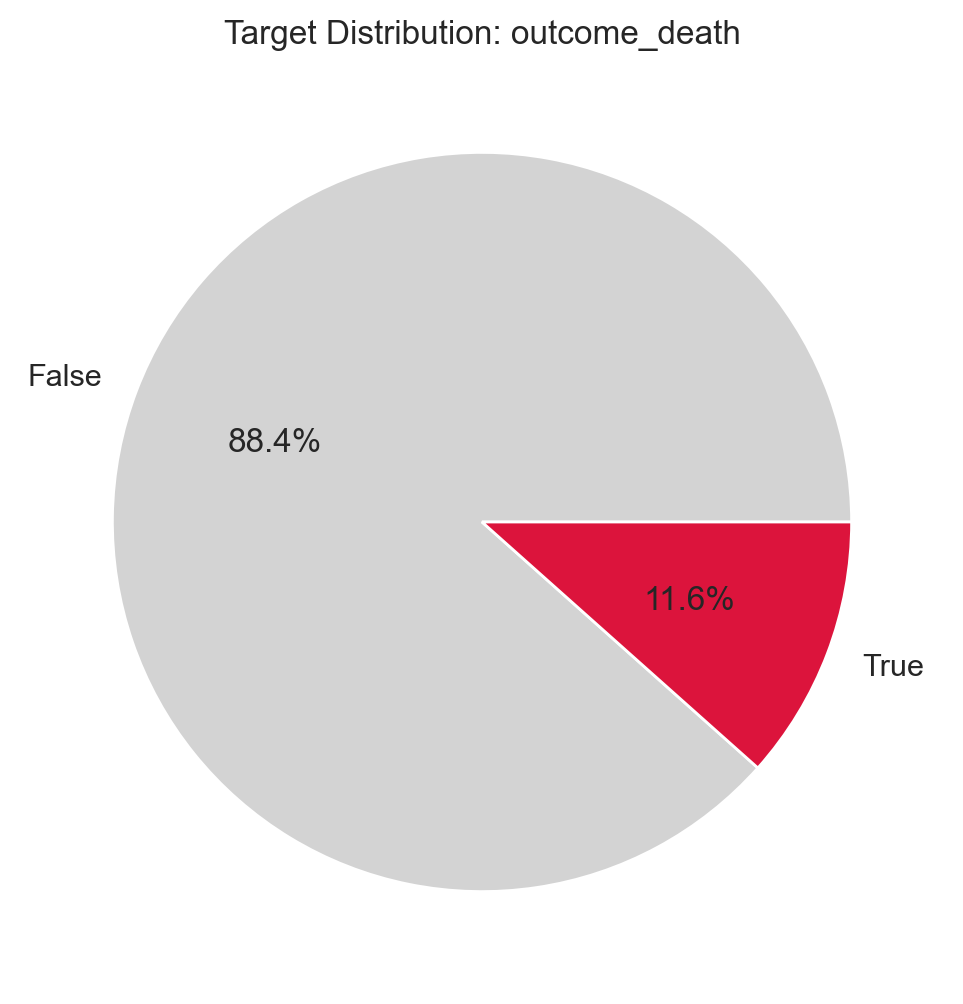

In [9]:
### F. Target Class Balance
TARGET_COL = 'outcome_death' # Or 'outcome_hospitalisation'

target_counts = (
    processed_lf.group_by(TARGET_COL)
    .count()
    .collect()
    .to_pandas()
)

plt.figure(figsize=(6, 6))
plt.pie(target_counts['count'], labels=target_counts[TARGET_COL], autopct='%1.1f%%', colors=['lightgrey', 'crimson'])
plt.title(f'Target Distribution: {TARGET_COL}')
plt.show()

Extracting age and target data...


C:\Users\Cole\AppData\Local\Temp\ipykernel_6968\4003470100.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x='outcome_death', y='age_years', palette='Set2', split=True)


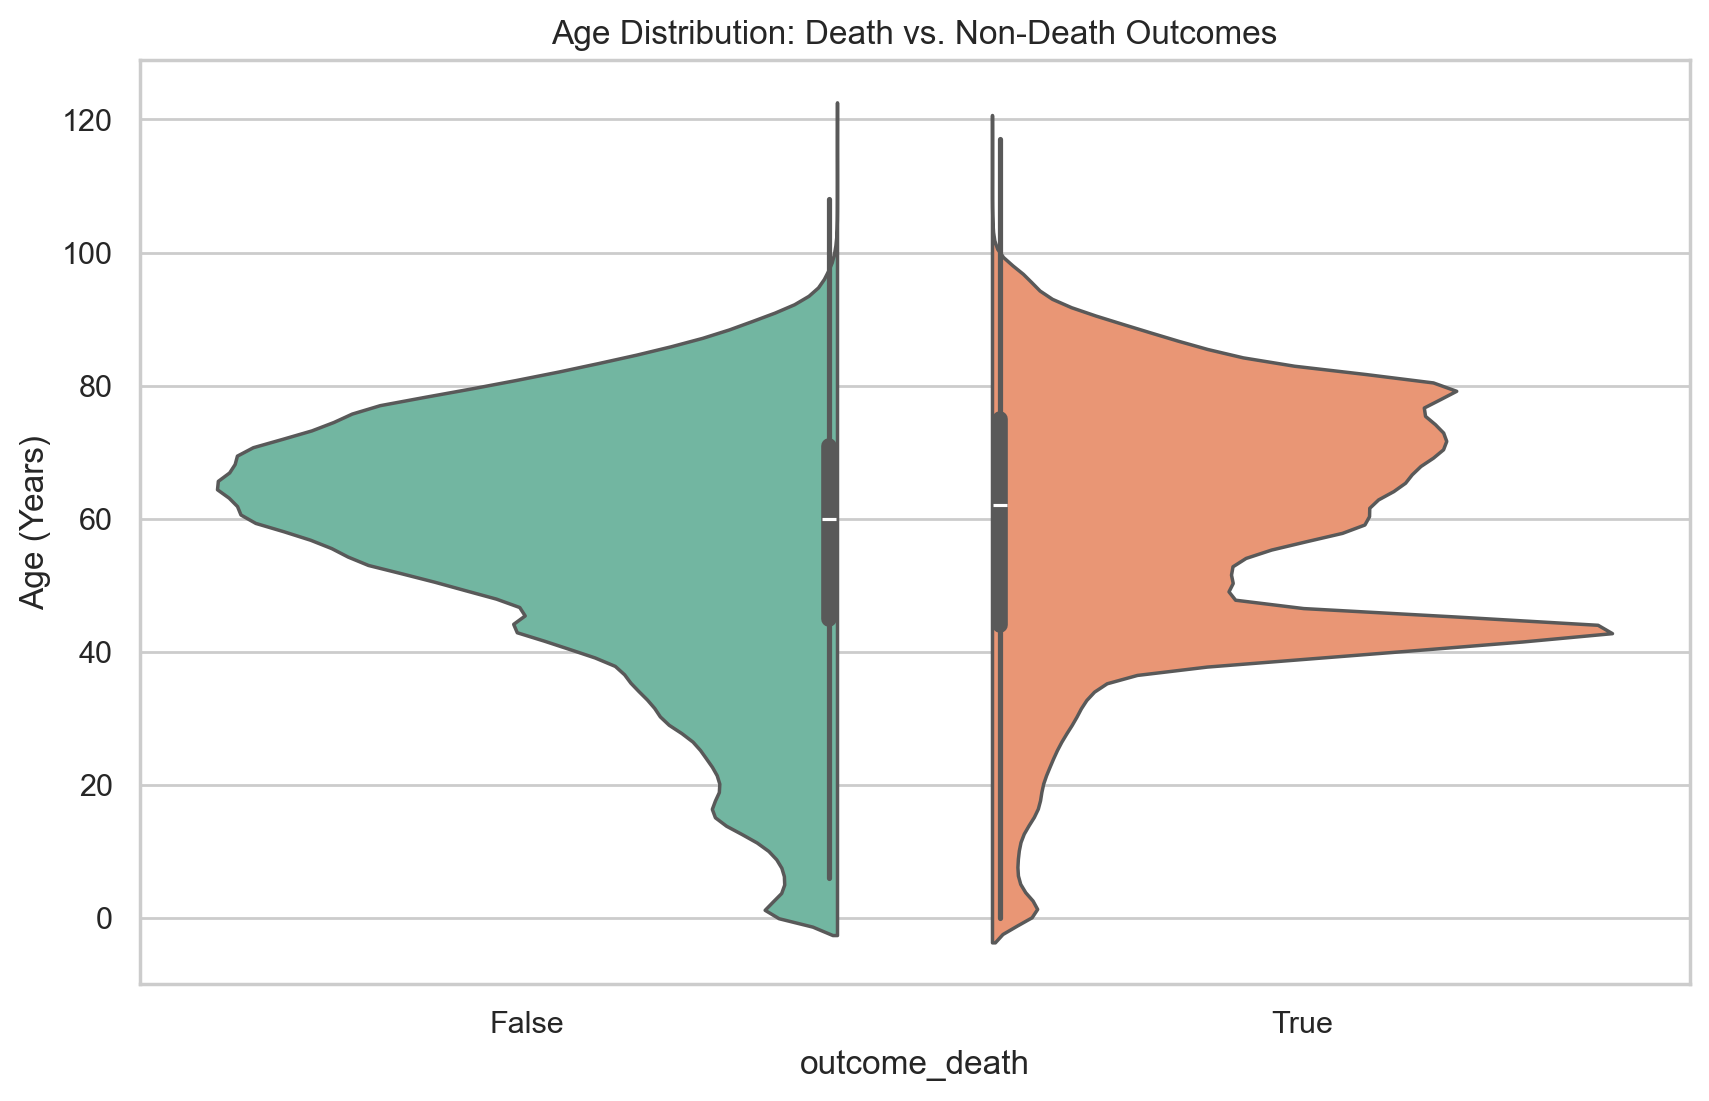

In [10]:
### G. Feature vs Target: Age vs Outcome
print("Extracting age and target data...")

# We sample a smaller subset (e.g., 1M rows) for the boxplot to keep it responsive
plot_data = (
    processed_lf.select(['age_years', 'outcome_death'])
    .drop_nulls()
    .collect()
    .sample(n=1_000_000) 
    .to_pandas()
)

plt.figure(figsize=(10, 6))
sns.violinplot(data=plot_data, x='outcome_death', y='age_years', palette='Set2', split=True)
plt.title('Age Distribution: Death vs. Non-Death Outcomes')
plt.ylabel('Age (Years)')
plt.show()

In [11]:
### H. Cardinality of Categorical Features
cat_cols = ['rx_name', 'sex', 'dose_form', 'role_cod']

cardinality = (
    processed_lf.select([
        pl.col(c).n_unique().alias(c)
        for c in cat_cols
    ])
    .collect()
    .to_pandas()
    .T
)

cardinality.columns = ['Unique Value Count']
print("Feature Cardinality (Unique counts):")
print(cardinality)

Feature Cardinality (Unique counts):
           Unique Value Count
rx_name                 60711
sex                         7
dose_form                4257
role_cod                    6


Calculating Top 10 lists using Streaming Engine...


C:\Users\Cole\AppData\Local\Temp\ipykernel_6968\1012301959.py:31: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  top_drugs = top_drugs_lf.collect(streaming=True)
C:\Users\Cole\AppData\Local\Temp\ipykernel_6968\1012301959.py:32: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  top_reactions = top_reactions_lf.collect(streaming=True)
C:\Users\Cole\AppData\Local\Temp\ipykernel_6968\1012301959.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_drugs.to_pandas(), x="len", y="rx_name", palette="Blues_r", ax=axes[0])
C:\Users\Cole\AppData\Local\Temp\ipykernel_6968\1012301959.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False`

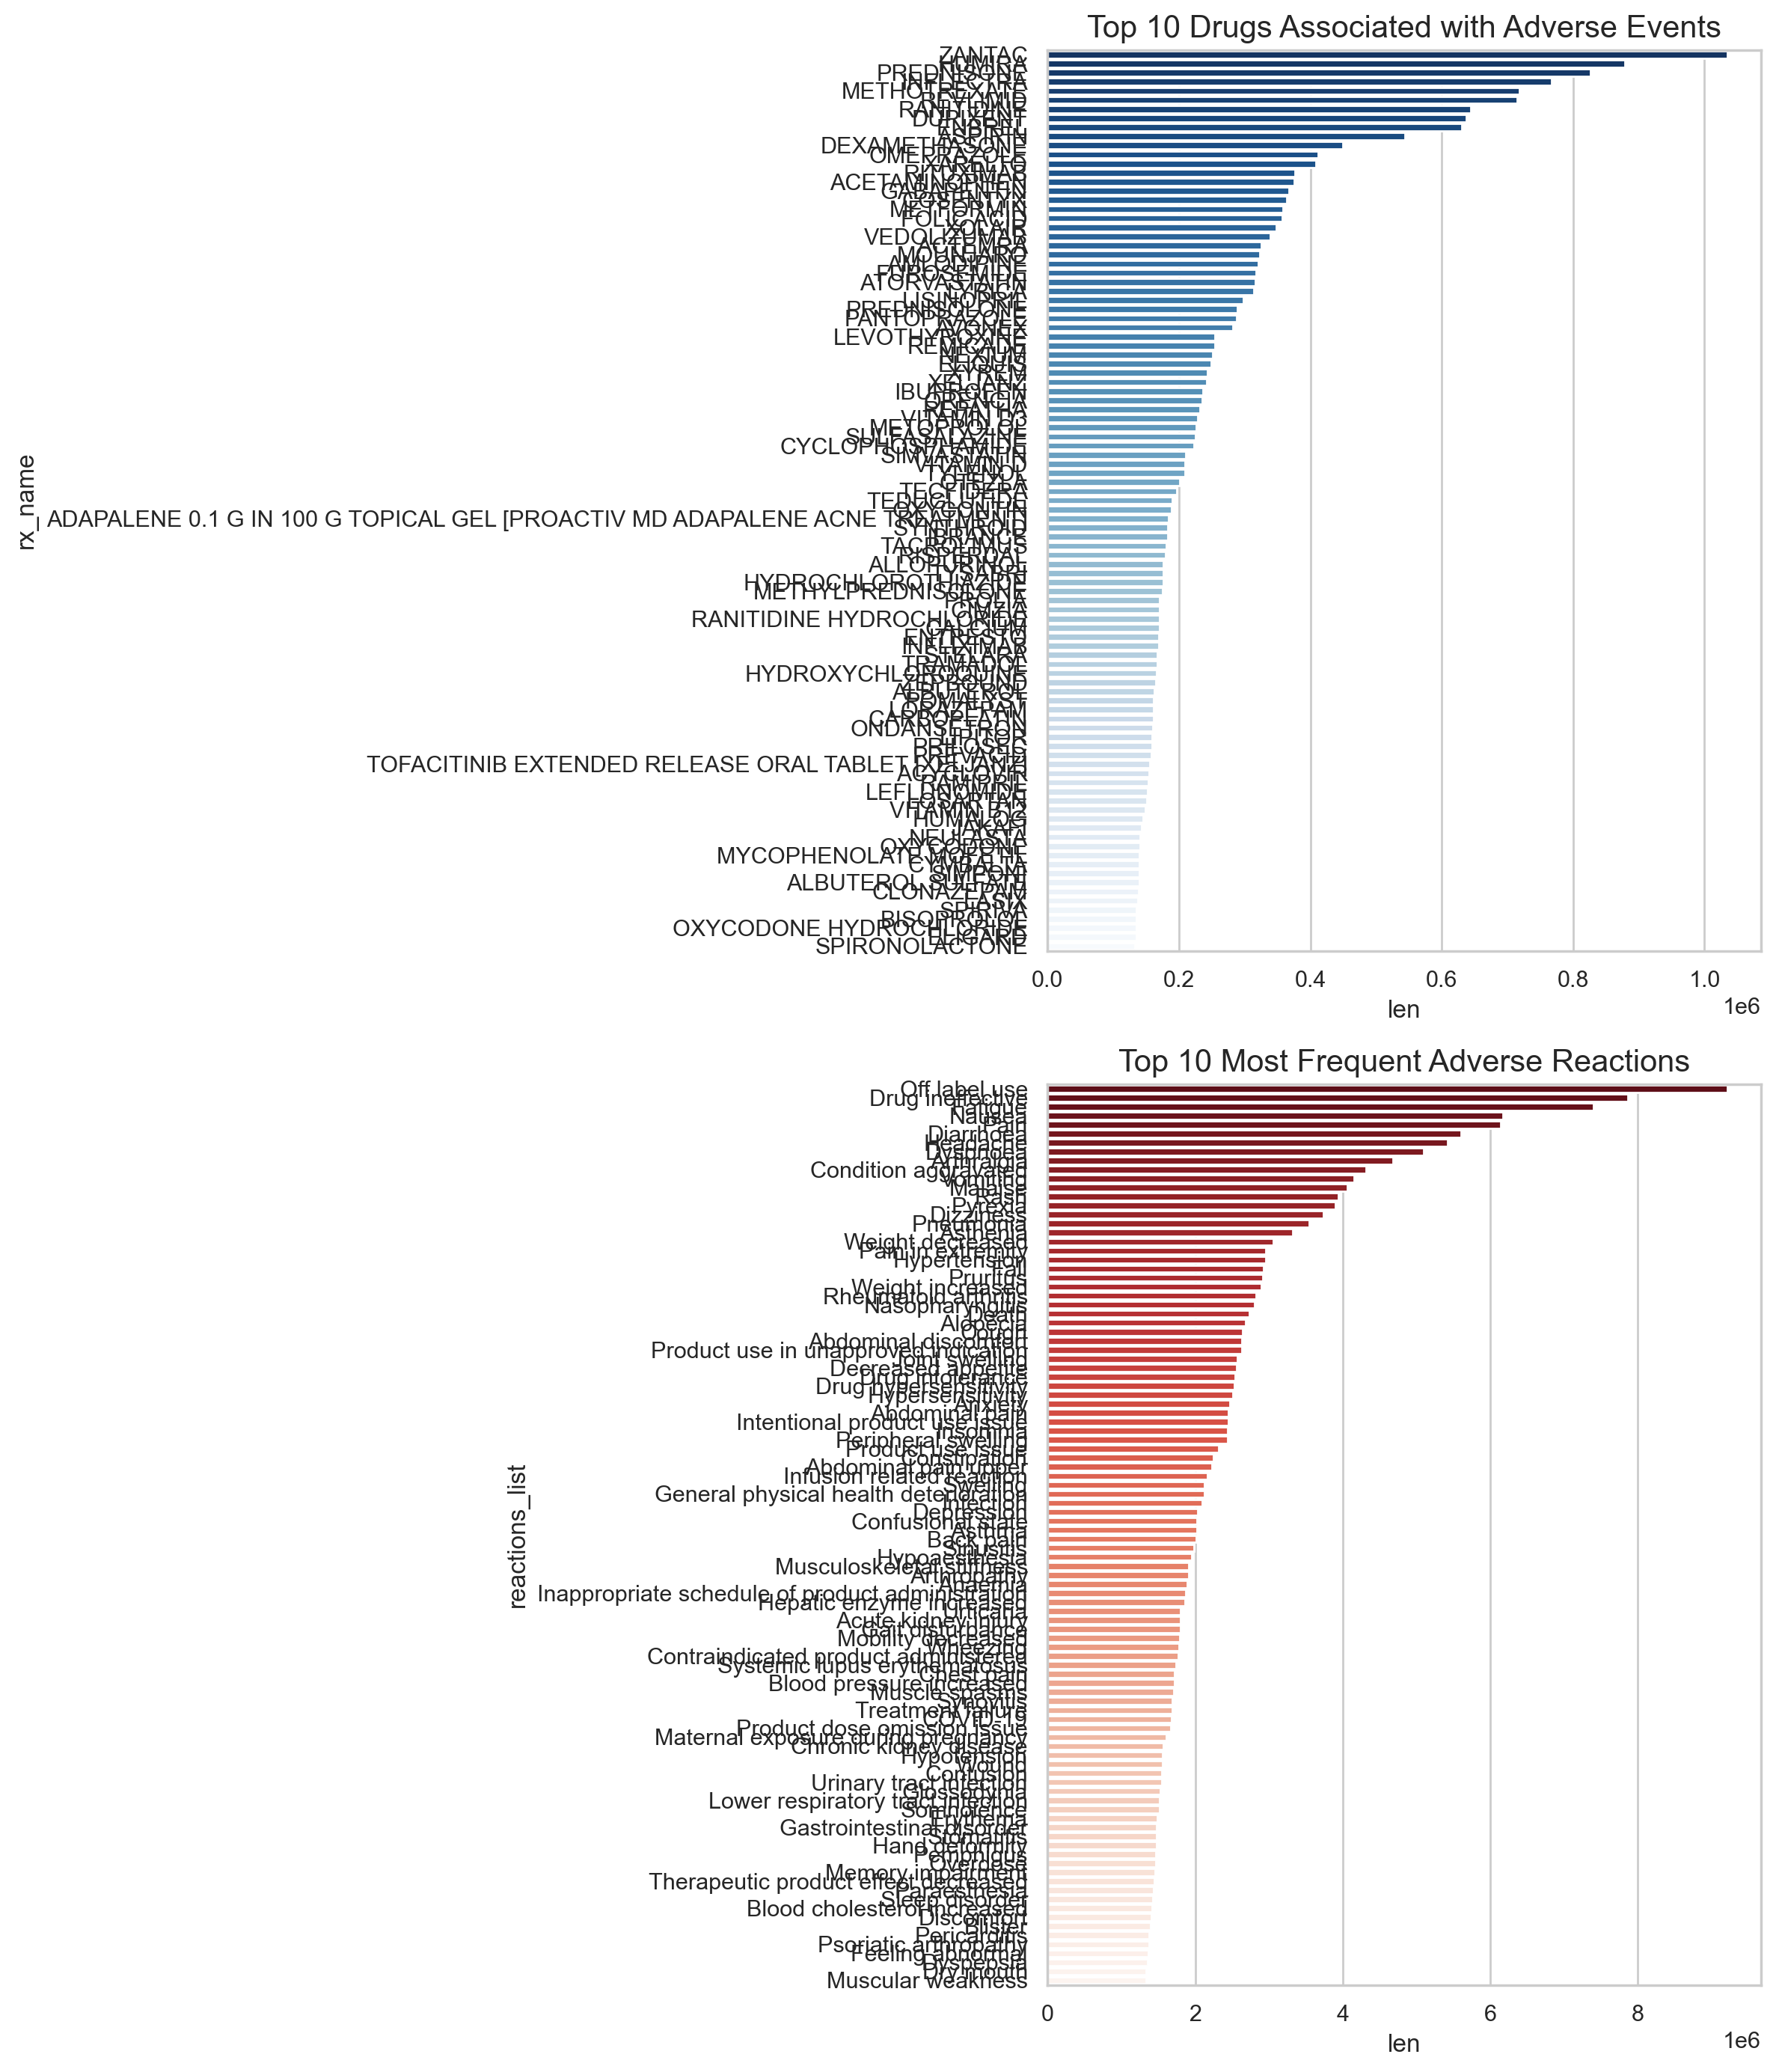

In [12]:
### C. Top 10 Drugs and Reactions (Optimized)

# 1. Process Top Drugs 
# Use .len() instead of .count() for a slight speed boost in newer Polars
top_drugs_lf = (
    processed_lf
    .group_by("rx_name")
    .len() 
    .sort("len", descending=True)
    .head(100)
)

# 2. Process Top Reactions (THE OPTIMIZED PART)
top_reactions_lf = (
    processed_lf
    .select("reactions_list")
    # Drop nulls/empty lists BEFORE exploding to save memory
    .drop_nulls() 
    .explode("reactions_list")
    .filter(pl.col("reactions_list") != "")
    .group_by("reactions_list")
    .len()
    .sort("len", descending=True)
    .head(100)
)

# 3. Trigger computation (Streaming mode is key for 81M rows!)
print("Calculating Top 10 lists using Streaming Engine...")

# We use streaming=True to handle the 400M+ exploded rows without crashing RAM
top_drugs = top_drugs_lf.collect(streaming=True)
top_reactions = top_reactions_lf.collect(streaming=True)

# 4. Plotting (Updating column names to 'len' from 'count')
fig, axes = plt.subplots(2, 1, figsize=(12, 14))

# Drug Chart
sns.barplot(data=top_drugs.to_pandas(), x="len", y="rx_name", palette="Blues_r", ax=axes[0])
axes[0].set_title("Top 10 Drugs Associated with Adverse Events", fontsize=15)

# Reaction Chart
sns.barplot(data=top_reactions.to_pandas(), x="len", y="reactions_list", palette="Reds_r", ax=axes[1])
axes[1].set_title("Top 10 Most Frequent Adverse Reactions", fontsize=15)

plt.tight_layout()
plt.show()